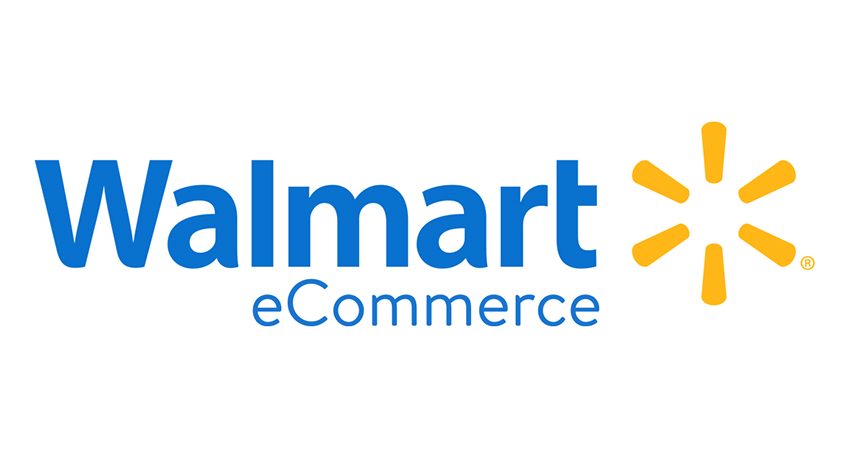

In [52]:
from IPython.display import Image, display
display(Image(filename="Images/walmartecomm.jpg"))



Walmart is the biggest retail store in the United States. Just like others, they have been expanding their e-commerce part of the business. By the end of 2022, e-commerce represented a roaring $80 billion in sales, which is 13% of total sales of Walmart. One of the main factors that affects their sales is public holidays, like the Super Bowl, Labour Day, Thanksgiving, and Christmas. 

In this project, you have been tasked with creating a data pipeline for the analysis of supply and demand around the holidays, along with conducting a preliminary analysis of the data. You will be working with two data sources: grocery sales and complementary data. You have been provided with the `grocery_sales` table in `PostgreSQL` database with the following features:

# `grocery_sales`
- `"index"` - unique ID of the row
- `"Store_ID"` - the store number
- `"Date"` - the week of sales
- `"Weekly_Sales"` - sales for the given store

Also, you have the `extra_data.parquet` file that contains complementary data:

# `extra_data.parquet`
- `"IsHoliday"` - Whether the week contains a public holiday - 1 if yes, 0 if no.
- `"Temperature"` - Temperature on the day of sale
- `"Fuel_Price"` - Cost of fuel in the region
- `"CPI"` – Prevailing consumer price index
- `"Unemployment"` - The prevailing unemployment rate
- `"MarkDown1"`, `"MarkDown2"`, `"MarkDown3"`, `"MarkDown4"` - number of promotional markdowns
- `"Dept"` - Department Number in each store
- `"Size"` - size of the store
- `"Type"` - type of the store (depends on `Size` column)

You will need to merge those files and perform some data manipulations. The transformed DataFrame can then be stored as the `clean_data` variable containing the following columns:
- `"Store_ID"`
- `"Month"`
- `"Dept"`
- `"IsHoliday"`
- `"Weekly_Sales"`
- `"CPI"`
- "`"Unemployment"`"

After merging and cleaning the data, you will have to analyze monthly sales of Walmart and store the results of your analysis as the `agg_data` variable that should look like:

|  Month | Weekly_Sales  | 
|---|---|
| 1.0  |  33174.178494 |
|  2.0 |  34333.326579 |
|  ... | ...  |  

Finally, you should save the `clean_data` and `agg_data` as the csv files.

It is recommended to use `pandas` for this project. 

In [ ]:
# --------------------------------------------------
# EXTRACT: LOAD DATA FROM POSTGRESQL DATABASE
# --------------------------------------------------
# Description:
# Establish a connection to a PostgreSQL database and
# retrieve grocery sales data using a SQL query.
#
# Why:
# In real-world data engineering workflows, data is often
# stored in relational databases. This step simulates
# extracting data from a production database system.
#
# Process:
# - Connect to PostgreSQL using psycopg2
# - Execute a SQL query to retrieve data
# - Load the result into a pandas DataFrame
#
# Output:
# A DataFrame (`grocery_sales`) containing raw sales data
# from the database.
# --------------------------------------------------

import psycopg2
import pandas as pd

# Establish database connection
conn = psycopg2.connect(
    host="YOUR_HOST",
    database="YOUR_DATABASE",
    user="YOUR_USERNAME",
    password="YOUR_PASSWORD"
)

# SQL query to fetch all records from the grocery sales table
query = "SELECT * FROM grocery_saless;"

# Load query result into a pandas DataFrame
grocery_sales = pd.read_sql(query, conn)

# Preview the first few rows of the dataset
print(grocery_sales.head())

In [41]:
# --------------------------------------------------
# EXTRACT: LOAD AND MERGE ADDITIONAL DATA
# --------------------------------------------------
# Description:
# Load additional data from a Parquet file and merge it
# with the main grocery sales dataset.
#
# Why:
# In real-world data pipelines, data often comes from
# multiple sources. Combining datasets enriches the data
# and enables more comprehensive analysis.
#
# Process:
# - Load extra data from a Parquet file
# - Merge it with the main dataset using a common key
#
# Output:
# A merged DataFrame (`merged_df`) that combines both
# datasets into a single structured table.
# --------------------------------------------------

import pandas as pd
import os
import numpy as np

# Extract function is already implemented for you 
def extract(store_data, extra_data):
    # Load additional dataset from parquet file
    extra_df = pd.read_parquet(extra_data)
    
    # Merge main dataset with additional data
    merged_df = store_data.merge(extra_df, on="index")
    
    return merged_df

# Call the extract() function and store result
merged_df = extract(grocery_sales, "data/extra_data (1).parquet")

In [42]:
# --------------------------------------------------
# TRANSFORM: CLEAN AND PREPARE DATA
# --------------------------------------------------
# Description:
# Clean and transform the merged dataset to prepare it
# for analysis and downstream processing.
#
# Why:
# Raw data often contains missing values, inconsistent
# formats, and irrelevant records. This step ensures
# data quality and usability.
#
# Process:
# - Convert date column to datetime format
# - Extract month information from date
# - Handle missing values appropriately
# - Filter out low sales records
# - Select relevant columns for analysis
#
# Output:
# A cleaned and structured DataFrame ready for loading.
# --------------------------------------------------

# Create the transform() function
def transform(raw_data):
    # Create a copy to avoid modifying original data
    df = raw_data.copy()

    # Convert "Date" column to datetime format
    df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

    # Extract month from the date column
    df["Month"] = df["Date"].dt.month

    # Identify numeric columns
    numeric_cols = df.select_dtypes(include=[np.number]).columns

    # Exclude "Month" from mean imputation
    numeric_cols = numeric_cols.drop("Month", errors="ignore")

    # Fill missing numeric values with column mean
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

    # Drop rows where "Month" could not be determined
    df = df.dropna(subset=["Month"])

    # Convert "Month" to integer
    df["Month"] = df["Month"].astype(int)

    # Filter out low sales values
    df = df[df["Weekly_Sales"] > 10000]

    # Select relevant columns for analysis
    df = df[[
        "Store_ID", "Month", "Dept", "IsHoliday",
        "Weekly_Sales", "CPI", "Unemployment"
    ]]

    return df

In [43]:
# --------------------------------------------------
# APPLY TRANSFORMATION STEP
# --------------------------------------------------
# Description:
# Apply the transformation function to the merged dataset.
#
# Why:
# This step executes the data cleaning and preparation logic,
# converting raw merged data into a structured and analysis-ready format.
#
# Output:
# A cleaned DataFrame (`clean_data`) ready for the loading phase.
# --------------------------------------------------

# Call the transform() function and process the merged dataset
clean_data = transform(merged_df)

In [44]:
# --------------------------------------------------
# ANALYSIS: AVERAGE WEEKLY SALES PER MONTH
# --------------------------------------------------
# Description:
# Calculate the average weekly sales for each month
# using the cleaned dataset.
#
# Why:
# Aggregating data helps uncover trends and patterns.
# Monthly averages provide insight into seasonal sales
# behavior and business performance over time.
#
# Process:
# - Select relevant columns (Month, Weekly_Sales)
# - Group data by Month
# - Compute average sales per month
# - Format and round results for readability
#
# Output:
# A DataFrame (`agg_df`) containing average monthly sales.
# --------------------------------------------------

# Create the avg_weekly_sales_per_month function
def avg_weekly_sales_per_month(clean_data):
    # Select only relevant columns for analysis
    df = clean_data[["Month", "Weekly_Sales"]]
    
    # Perform aggregation: average sales per month
    agg_df = (
        df.groupby("Month")                           # Group by month
          .agg(Avg_Sales=("Weekly_Sales", "mean"))    # Calculate average sales
          .reset_index()                              # Convert index back to column
          .round(2)                                   # Round values for readability
    )
    
    return agg_df

In [45]:
# --------------------------------------------------
# EXECUTE ANALYSIS STEP
# --------------------------------------------------
# Description:
# Apply the aggregation function to compute average
# weekly sales per month.
#
# Why:
# This step transforms processed data into meaningful
# business insights, enabling trend analysis and
# performance evaluation.
#
# Output:
# A DataFrame (`agg_data`) containing average sales
# values for each month.
# --------------------------------------------------

# Call the aggregation function using cleaned data
agg_data = avg_weekly_sales_per_month(clean_data)

In [46]:
# --------------------------------------------------
# LOAD: SAVE PROCESSED AND ANALYZED DATA
# --------------------------------------------------
# Description:
# Save both the cleaned dataset and the aggregated
# analysis results to CSV files.
#
# Why:
# The load step makes the processed data available
# for downstream use such as reporting, dashboards,
# or further analysis.
#
# Process:
# - Save the cleaned full dataset
# - Save the aggregated (analysis) dataset
# - Provide a confirmation message
#
# Output:
# Two CSV files:
# - Full cleaned dataset
# - Aggregated monthly sales data
# --------------------------------------------------

# Create the load() function
def load(full_data, full_data_file_path, agg_data, agg_data_file_path):
    
    # Save cleaned dataset
    full_data.to_csv(full_data_file_path, index=False)
    
    # Save aggregated dataset
    agg_data.to_csv(agg_data_file_path, index=False)
    
    # Confirmation message
    print("Files successfully saved.")

In [47]:
# --------------------------------------------------
# EXECUTE LOAD STEP
# --------------------------------------------------
# Description:
# Execute the load function to save both the cleaned
# dataset and the aggregated analysis results.
#
# Why:
# This step finalizes the ETL pipeline by persisting
# processed data, making it available for downstream
# applications such as reporting or dashboards.
#
# Output:
# - Cleaned dataset saved as CSV
# - Aggregated dataset saved as CSV
# --------------------------------------------------

# Run the load function with output file paths
load(
    clean_data,
    "output/clean_data.csv",
    agg_data,
    "output/agg_data.csv"
)

Files successfully saved.


In [48]:
# --------------------------------------------------
# VALIDATION: CHECK OUTPUT FILE EXISTENCE
# --------------------------------------------------
# Description:
# Validate whether the output file has been successfully
# created after the load step.
#
# Why:
# In real-world data pipelines, validation is essential
# to ensure that each step has been executed correctly.
# This prevents silent failures and improves reliability.
#
# Process:
# - Check if the specified file exists in the given path
#
# Output:
# Returns True if the file exists, otherwise False
# --------------------------------------------------

# Create the validation() function
def validation(file_path):
    """
    Check whether a given file exists in the current working directory.

    Parameters:
        file_path (str): Path of the file to be validated

    Returns:
        bool: True if the file exists, False otherwise
    """
    return os.path.exists(file_path)

In [49]:
# --------------------------------------------------
# EXECUTE VALIDATION STEP
# --------------------------------------------------
# Description:
# Validate whether the output files were successfully
# created after the load step.
#
# Why:
# This step ensures that the ETL pipeline completed
# correctly and that the expected output files exist.
# It helps detect failures in the pipeline.
#
# Output:
# Boolean results indicating whether each file exists.
# --------------------------------------------------

# Validate existence of output files
validation("output/clean_data.csv")
validation("output/agg_data.csv")

True

In [50]:
# --------------------------------------------------
# DISPLAY FINAL AGGREGATED RESULTS
# --------------------------------------------------
# Description:
# Display the aggregated dataset containing average
# weekly sales per month.
#
# Why:
# This allows us to verify the results of the analysis
# and quickly inspect the output of the pipeline.
#
# Output:
# Printed DataFrame showing monthly average sales.
# --------------------------------------------------

print(agg_data)

    Month  Avg_Sales
0       1   33174.18
1       2   34333.33
2       3   33220.89
3       4   33392.37
4       5   33339.89
5       6   34582.47
6       7   33922.76
7       8   33644.79
8       9   33258.05
9      10   32736.99
10     11   36594.03
11     12   39238.80
